In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


from src.safe_routing import*
from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')
df = df.iloc[:50_000]

In [10]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133037,192.168.10.25-54.192.37.17-54988-443-6,54.192.37.17,443,192.168.10.25,54988,6,2017-04-07 01:00:00,54,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
394262,192.168.10.9-87.250.250.119-5303-443-6,87.250.250.119,443,192.168.10.9,5303,6,2017-04-07 01:00:00,101114,2,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132995,192.168.10.25-52.84.145.136-54978-443-6,192.168.10.25,54978,52.84.145.136,443,6,2017-04-07 01:00:00,169399,22,30,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132994,192.168.10.9-87.250.250.119-5260-443-6,192.168.10.9,5260,87.250.250.119,443,6,2017-04-07 01:00:00,148,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
138980,192.168.10.12-199.182.221.110-123-123-17,192.168.10.12,123,199.182.221.110,123,17,2017-04-07 01:00:00,71771,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178315,192.168.10.1-192.168.10.3-53-61396-17,192.168.10.3,61396,192.168.10.1,53,17,2017-04-07 02:14:00,38654,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
386100,192.168.10.25-54.192.37.69-57412-443-6,54.192.37.69,443,192.168.10.25,57412,6,2017-04-07 02:14:00,85,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
164392,192.168.10.25-23.203.72.172-57365-443-6,23.203.72.172,443,192.168.10.25,57365,6,2017-04-07 02:14:00,3,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
317065,192.168.10.3-192.168.10.50-53-35379-17,192.168.10.50,35379,192.168.10.3,53,17,2017-04-07 02:14:00,171,2,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [3]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [5]:
import src.network_plotting, importlib

importlib.reload(src.safe_routing)
from src.safe_routing import*

In [4]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False, spanning_tree=True)
entity_names = list(g.nodes)
len(g), len(entity_names)

(63, 63)

Conditioning number:  7923870499515677.0 
Determinant of F^T*F:  1.5695364726019278e-29


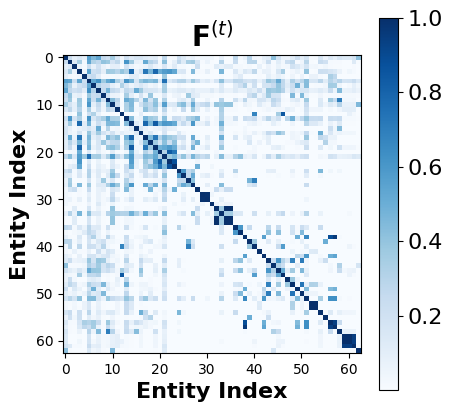

In [5]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

cu.fit_graph_model(method = 'cov') # cov
cu.plot_f(labels=True)
mat_F = cu.F.copy()

In [13]:
from src.analyze_cic_ids import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\layout_63.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov, mat_F, g), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:02:00 (75, 63)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 63)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 63)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 63)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 63)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 63)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 63)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 63)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 63)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 63)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 63)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 63)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 63)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 63)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 63)
16
Current time and samples shape:

In [6]:
with open(r'saves\layout_63.pickle', 'rb') as handle:
    risk_mean, risk_cov, mat_F, g = pickle.load(handle) 

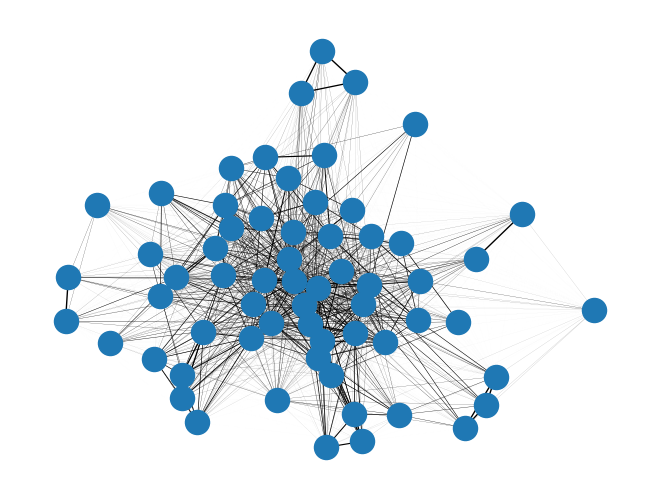

In [7]:
g_f = nx.from_numpy_array(mat_F - np.diag(np.diag(mat_F)))
nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)
pos_f = nx.spring_layout(g_f, seed=28)
widths = [g_f[u][v]['weight'] for u,v in g_f.edges]
nx.draw(g_f, pos=pos_f, width=widths, with_labels=False)

In [157]:
import src.network_plotting, importlib

importlib.reload(src.network_plotting)
from src.network_plotting import*

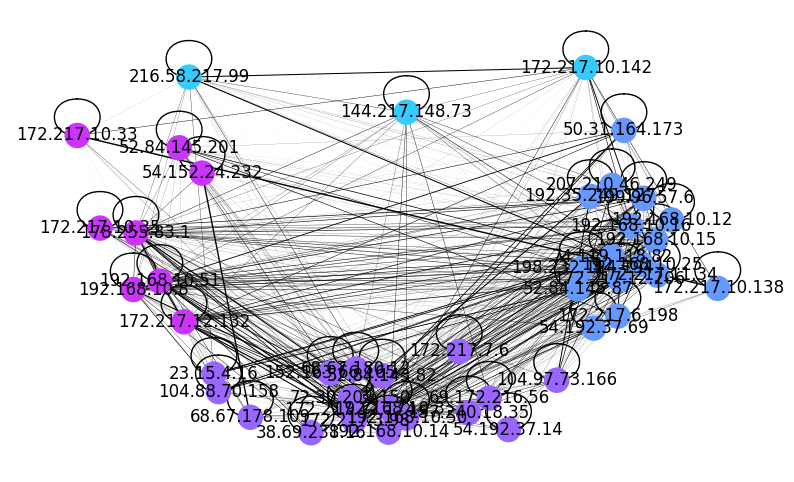

In [173]:
d = 1.3
pos_pie, node_colors, r, gt = pie_layout(mat_F, entity_names, n_cluster, d=d, r_const=2.5, plot_bool=True)

In [174]:
pos_dict = {name: pos_pie[name].tolist() for name in pos_pie}
edges_list = list(nx.minimum_spanning_tree(gt).edges)
risk_mean_dict = {name: val.tolist() for name, val in zip(gt.nodes, risk_mean)}
risk_cov_list = risk_cov.tolist()
g_f_adj = nx.adjacency_matrix(gt).todense().tolist()
color_dict = {name: color for name, color in zip(gt.nodes, node_colors)}
extras = {'n_cluster': n_cluster, 'diam': d, 'radius': r}

In [175]:
pos2json(r"../src/network_rendering/saves/net_data_63", pos = pos_dict, topologyEdges=edges_list, risk_mean=risk_mean_dict,
         risk_cov = risk_cov_list, funcEdges=g_f_adj, entityColors=color_dict, extras=extras)